
# Programación Evolutiva y Problemas Multiobjetivo  
## Reto con NSGA-II + `pymoo` (PEVO & PMOB)

Este cuaderno resuelve la actividad del documento **"Programación evolutiva y problemas multiobjetivo"** fileciteturn3file0, adaptando el código base de NSGA-II con `pymoo` para:

1. Incluir una **restricción presupuestaria**:
   \begin{equation}
   1 \cdot x_1 + 0.8 \cdot x_2 \le 12
   \end{equation}
2. Modificar la función de **Rendimiento Financiero** para que tenga **rendimientos decrecientes** en la inversión tecnológica \(x_1\):
   - Función original:  
     \(\text{RF}(x_1, x_2) = (x_1 + 1)^2 + 0.5x_2 - 0.1x_2^2\)
   - Función nueva:  
     \(\text{RF}_{nuevo}(x_1, x_2) = 10\sqrt{x_1 + 1} + 0.5x_2 - 0.1x_2^2\)

También se responden las preguntas de análisis (a, b, c) al final del cuaderno.



## 1. Instalación de dependencias

En Google Colab es necesario instalar `pymoo` (y asegurarse de tener `matplotlib` y `numpy`).  
Ejecuta la siguiente celda antes de continuar.


In [ ]:

!pip install -U pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.5/309.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.8/786.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.1 MB/s eta 0:00:00



## 2. Importación de librerías


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize


# 2.1 Código original

In [ ]:
# 1. Definición del Problema
class ProblemaFinanciero(ElementwiseProblem):
 def __init__(self):
    super().__init__(n_var=2, # x1: NIT, x2: GES
    n_obj=2, # RF, GA
    n_constr=0, # Sin restricciones adicionales por ahora
    xl=np.array([0, 0]), # Límites inferiores para x1, x2
    xu=np.array([10, 10]))# Límites superiores para x1, x2
 def _evaluate(self, x, out, *args, **kwargs):
  x1, x2 = x[0], x[1] # Desempaquetamos las variables de decisión
  # Objetivo 1: Maximizar Rendimiento Financiero (RF)
  # Como NSGA-II minimiza, debemos pasar -RF
  rf = (x1 + 1)**2 + 0.5*x2 - 0.1*x2**2
  obj1 = -rf # Minimizar -RF es maximizar RF
  # Objetivo 2: Minimizar Gastos Administrativos (GA)
  ga = 50 / (x2 + 1) + 0.2*(x1 - 5)**2 + 5
  obj2 = ga
  out["F"] = [obj1, obj2]
# Instanciar el problema
problem = ProblemaFinanciero()

In [ ]:
# 2. Configuración del Algoritmo NSGA-II
algorithm = NSGA2(
 eliminate_duplicates=True # Buena práctica
)

In [ ]:
# 3. Ejecución de la Optimización
res_old = minimize(problem,
 algorithm,
 ('n_gen', 200), # Número de generaciones
 seed=1, # Para reproducibilidad
 verbose=True) # Muest

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     15 |             - |             -
     2 |      200 |     20 |  0.0050598592 |         ideal
     3 |      300 |     38 |  0.0174808971 |             f
     4 |      400 |     42 |  0.0097943089 |             f
     5 |      500 |     59 |  0.1615041217 |         nadir
     6 |      600 |     86 |  0.0042069477 |         nadir
     7 |      700 |    100 |  0.0694225371 |         nadir
     8 |      800 |    100 |  0.0031824723 |             f
     9 |      900 |    100 |  0.0023046630 |             f
    10 |     1000 |    100 |  0.0220136140 |         nadir
    11 |     1100 |    100 |  0.0016757150 |             f
    12 |     1200 |    100 |  0.0442683194 |         nadir
    13 |     1300 |    100 |  0.0015101561 |             f
    14 |     1400 |    100 |  0.0028471641 |             f
    15 |     1500 |    100 |  0.0015023491 |             f
    16 |     1600 |    100 |  0.0024671570 |            

In [ ]:
# 4. Extracción y Preparación de Resultados para Graficar
# res.F contiene los valores de los objetivos para las soluciones del frente de Pareto
# Recordar que el primer objetivo (RF) está negado
pareto_rf = -res_old.F[:, 0] # Rendimiento Financiero (original, maximizar)
pareto_ga = res_old.F[:, 1] # Gastos Administrativos (original, minimizar)
# También podemos obtener las variables de decisión (x1, x2) para cada solución del frente
pareto_x1 = res_old.X[:, 0]
pareto_x2 = res_old.X[:, 1]

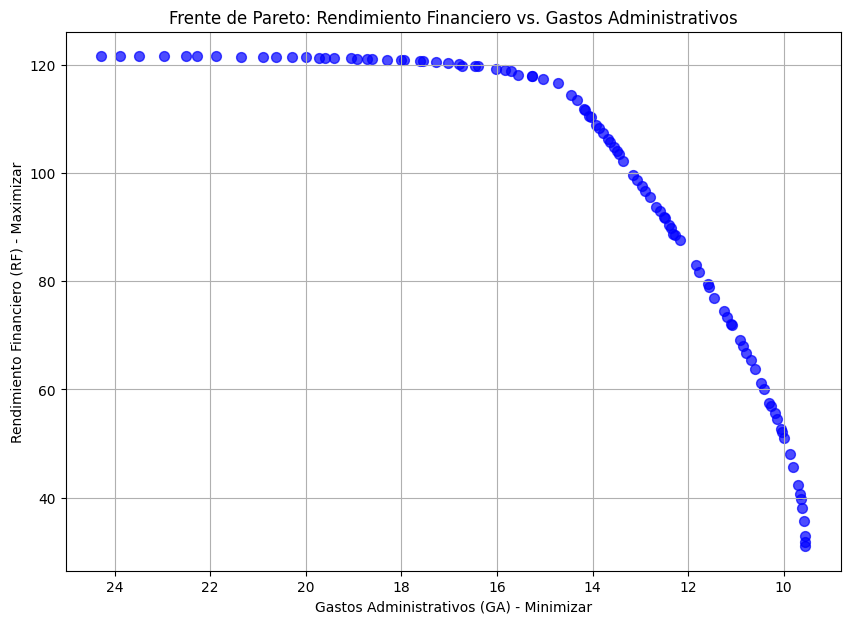

In [ ]:
# 5. Visualización del Frente de Pareto
plt.figure(figsize=(10, 7))
plt.scatter(pareto_ga, pareto_rf, s=50, facecolors='blue', edgecolors='blue', alpha=0.7)
plt.title('Frente de Pareto: Rendimiento Financiero vs. Gastos Administrativos')
plt.xlabel('Gastos Administrativos (GA) - Minimizar')
plt.ylabel('Rendimiento Financiero (RF) - Maximizar')
plt.grid(True)
plt.gca().invert_xaxis() # Opcional: A veces es intuitivo tener "mejor" hacia la derecha para minimizar
 # Pero el estándar es menor a la izquierda, mayor a la derecha.
 # Para GA (minimizar), menor es mejor, así que lo dejamos estándar.
 # RF (maximizar), mayor es mejor, así que estándar está bien.
plt.show()

In [ ]:
print("\nAlgunas soluciones del Frente de Pareto (x1: NIT, x2: GES, RF, GA):")
for i in range(min(10, len(pareto_rf))): # Mostramos hasta 10 soluciones
 print(f"Sol {i+1}: NIT={pareto_x1[i]:.2f}, GES={pareto_x2[i]:.2f} -> RF={pareto_rf[i]:.2f},GA={pareto_ga[i]:.2f}")


Algunas soluciones del Frente de Pareto (x1: NIT, x2: GES, RF, GA):
Sol 1: NIT=10.00, GES=2.50 -> RF=121.62,GA=24.29
Sol 2: NIT=5.00, GES=10.00 -> RF=31.00,GA=9.55
Sol 3: NIT=5.88, GES=10.00 -> RF=42.36,GA=9.70
Sol 4: NIT=8.31, GES=9.93 -> RF=81.79,GA=11.77
Sol 5: NIT=10.00, GES=2.60 -> RF=121.62,GA=23.88
Sol 6: NIT=10.00, GES=8.90 -> RF=117.45,GA=15.05
Sol 7: NIT=10.00, GES=2.86 -> RF=121.61,GA=22.96
Sol 8: NIT=7.07, GES=10.00 -> RF=60.15,GA=10.40
Sol 9: NIT=6.28, GES=10.00 -> RF=48.06,GA=9.88
Sol 10: NIT=7.77, GES=9.99 -> RF=71.98,GA=11.09


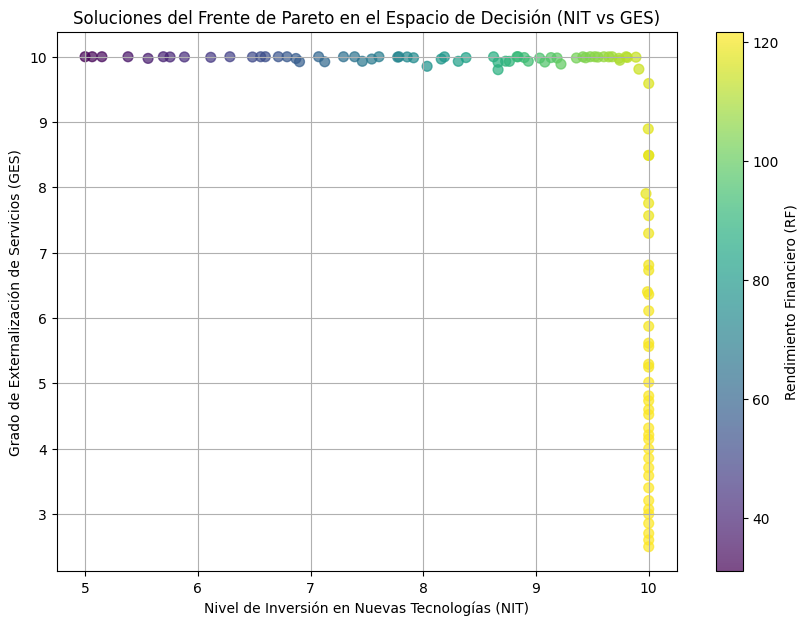

In [ ]:
# Opcional: Visualización en el espacio de decisión
# Esto puede ayudar a entender qué combinaciones de x1 y x2 llevan al frente.
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pareto_x1, pareto_x2, c=pareto_rf, cmap='viridis', s=50, alpha=0.7)
plt.title('Soluciones del Frente de Pareto en el Espacio de Decisión (NIT vs GES)')
plt.xlabel('Nivel de Inversión en Nuevas Tecnologías (NIT)')
plt.ylabel('Grado de Externalización de Servicios (GES)')
cbar = plt.colorbar(scatter, label='Rendimiento Financiero (RF)')
plt.grid(True)
plt.show()

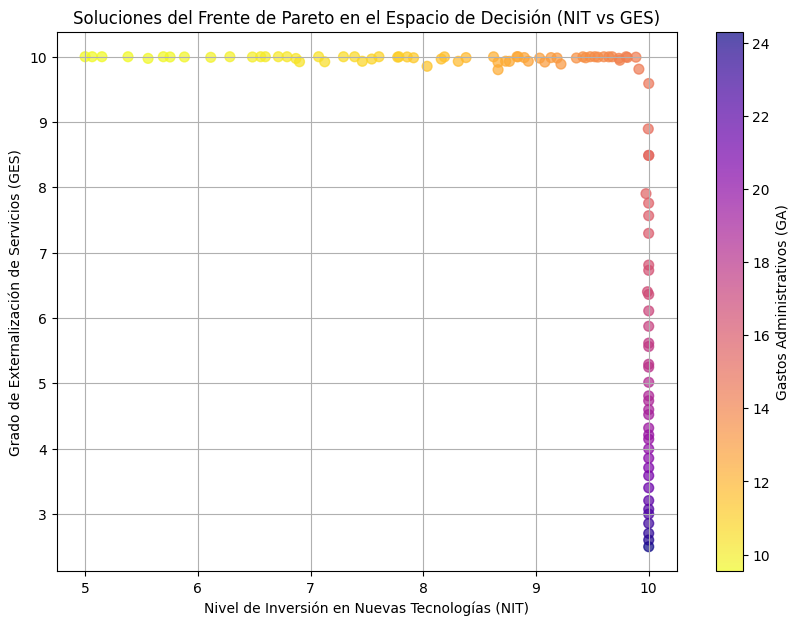

In [ ]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pareto_x1, pareto_x2, c=pareto_ga, cmap='plasma_r', s=50, alpha=0.7) # _r invierte el colormap
plt.title('Soluciones del Frente de Pareto en el Espacio de Decisión (NIT vs GES)')
plt.xlabel('Nivel de Inversión en Nuevas Tecnologías (NIT)')
plt.ylabel('Grado de Externalización de Servicios (GES)')
cbar = plt.colorbar(scatter, label='Gastos Administrativos (GA)')
plt.grid(True)
plt.show()


## 3. Definición del problema financiero modificado

Recordemos el contexto:

- Objetivo 1: **Maximizar Rendimiento Financiero (RF)**  
- Objetivo 2: **Minimizar Gastos Administrativos (GA)**  
- Variables de decisión:
  - \(x_1\): Nivel de Inversión en Nuevas Tecnologías (NIT) \([0, 10]\)
  - \(x_2\): Grado de Externalización de Servicios (GES) \([0, 10]\)

### 3.1. Nueva función de Rendimiento Financiero (RF)

Modelo con **rendimientos decrecientes en \(x_1\)**:

\begin{equation}
\text{RF}_{nuevo}(x_1, x_2) = 10\sqrt{x_1 + 1} + 0.5x_2 - 0.1x_2^2
\end{equation}

- El término \(10\sqrt{x_1 + 1}\) crece cada vez más lento según aumenta \(x_1\).
- \(x_2\) tiene un efecto positivo inicial pero se vuelve perjudicial para valores altos por el término \(-0.1x_2^2\).

### 3.2. Función de Gastos Administrativos (GA)

Se mantiene igual que en el enunciado original:

\begin{equation}
\text{GA}(x_1, x_2) = \frac{50}{x_2 + 1} + 0.2(x_1 - 5)^2 + 5
\end{equation}

### 3.3. Restricción presupuestaria

Cada unidad de \(x_1\) cuesta **1** unidad monetaria.  
Cada unidad de \(x_2\) cuesta **0.8** unidades monetarias.  

Presupuesto máximo: **12** unidades monetarias:

\begin{equation}
1\cdot x_1 + 0.8 \cdot x_2 \le 12
\end{equation}

En `pymoo`, las restricciones se modelan como:
\begin{equation}
g(x) \le 0
\end{equation}

Por tanto, definimos:

\begin{equation}
g_1(x) = 1\cdot x_1 + 0.8\cdot x_2 - 12 \le 0
\end{equation}



## 4. Implementación del problema en `pymoo` (con restricción + RF modificada)


In [ ]:

class ProblemaFinancieroMod(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=2,          # x1: NIT, x2: GES
            n_obj=2,          # Objetivo 1: RF (max → min de -RF), Objetivo 2: GA (min)
            n_constr=1,       # Una restricción: presupuesto ----- valor debe ir en 0
            xl=np.array([0, 0]),   # Límites inferiores para x1, x2
            xu=np.array([10, 10])  # Límites superiores para x1, x2
        )

    def _evaluate(self, x, out, *args, **kwargs):
        x1, x2 = x[0], x[1]

        # --- Objetivo 1: Maximizar Rendimiento Financiero (RF_nuevo) ---
        # RF_nuevo(x1, x2) = 10*sqrt(x1 + 1) + 0.5*x2 - 0.1*x2^2
        rf_nuevo = 10 * np.sqrt(x1 + 1.0) + 0.5 * x2 - 0.1 * x2**2
        obj1 = -rf_nuevo        # NSGA-II minimiza, por eso se usa -RF

        # --- Objetivo 2: Minimizar Gastos Administrativos (GA) ---
        ga = 50.0 / (x2 + 1.0) + 0.2 * (x1 - 5.0)**2 + 5.0
        obj2 = ga

        # --- Restricción de presupuesto ---
        # g1(x) = 1*x1 + 0.8*x2 - 12 <= 0
        g1 = 1.0 * x1 + 0.8 * x2 - 12.0

        out["F"] = [obj1, obj2]
        out["G"] = [g1]



## 5. Ejecución del algoritmo NSGA-II


In [ ]:

# Instanciar el problema
problem = ProblemaFinancieroMod()

# Configurar el algoritmo NSGA-II
algorithm = NSGA2(
    pop_size=100,
    eliminate_duplicates=True
)

# Ejecutar la optimización
res_new = minimize(
    problem,
    algorithm,
    ('n_gen', 200),  # número de generaciones
    seed=1,
    verbose=True
)

# Extraer valores de objetivos y variables de decisión
pareto_rf = -res_new.F[:, 0]   # RF original (ya no negado)
pareto_ga = res_new.F[:, 1]    # GA
pareto_x1 = res_new.X[:, 0]    # NIT
pareto_x2 = res_new.X[:, 1]    # GES

print("Número de soluciones no dominadas encontradas:", len(pareto_rf))


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |     12 |  0.000000E+00 |  0.3623144763 |             - |             -
     2 |      200 |     20 |  0.000000E+00 |  0.000000E+00 |  0.0687578435 |         nadir
     3 |      300 |     28 |  0.000000E+00 |  0.000000E+00 |  0.0132362805 |         nadir
     4 |      400 |     34 |  0.000000E+00 |  0.000000E+00 |  0.0032205912 |         ideal
     5 |      500 |     43 |  0.000000E+00 |  0.000000E+00 |  0.0143673107 |         nadir
     6 |      600 |     48 |  0.000000E+00 |  0.000000E+00 |  0.0201663220 |         nadir
     7 |      700 |     68 |  0.000000E+00 |  0.000000E+00 |  0.0046873752 |             f
     8 |      800 |     77 |  0.000000E+00 |  0.000000E+00 |  0.0017239744 |             f
     9 |      900 |     86 |  0.000000E+00 |  0.000000E+00 |  0.0045417244 |             f
    10 |     1000 |    100 |  0.000000E+00 |  0.000000E+00 |  0.0039816225 |         nadir


## 6. Visualización del nuevo Frente de Pareto


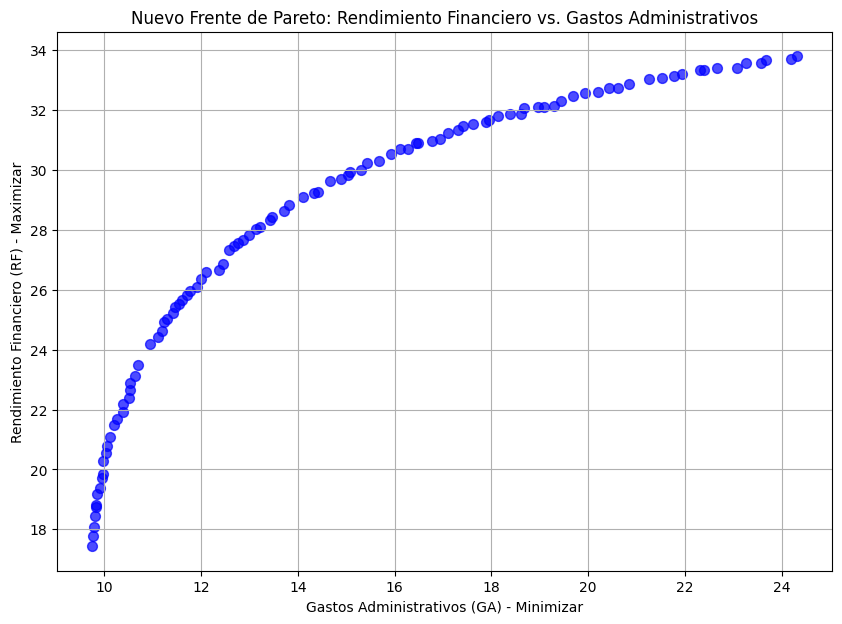

Algunas soluciones del Frente de Pareto (x1: NIT, x2: GES, RF, GA):
Sol 1: NIT=10.00, GES=2.49 -> RF=33.79, GA=24.31
Sol 2: NIT=4.02, GES=9.98 -> RF=17.44, GA=9.75
Sol 3: NIT=9.43, GES=3.19 -> RF=32.87, GA=20.85
Sol 4: NIT=7.84, GES=5.20 -> RF=29.62, GA=14.67
Sol 5: NIT=9.52, GES=3.10 -> RF=33.02, GA=21.27
Sol 6: NIT=7.62, GES=5.47 -> RF=29.11, GA=14.11
Sol 7: NIT=6.63, GES=6.24 -> RF=26.86, GA=12.44
Sol 8: NIT=7.51, GES=5.61 -> RF=28.82, GA=13.82
Sol 9: NIT=6.92, GES=6.31 -> RF=27.32, GA=12.58
Sol 10: NIT=9.74, GES=2.80 -> RF=33.39, GA=22.67


In [ ]:

plt.figure(figsize=(10, 7))
plt.scatter(pareto_ga, pareto_rf, s=50, facecolors='blue', edgecolors='blue', alpha=0.7)
plt.title('Nuevo Frente de Pareto: Rendimiento Financiero vs. Gastos Administrativos')
plt.xlabel('Gastos Administrativos (GA) - Minimizar')
plt.ylabel('Rendimiento Financiero (RF) - Maximizar')
plt.grid(True)
plt.show()

print("Algunas soluciones del Frente de Pareto (x1: NIT, x2: GES, RF, GA):")
for i in range(min(10, len(pareto_rf))):
    print(f"Sol {i+1}: NIT={pareto_x1[i]:.2f}, GES={pareto_x2[i]:.2f} -> RF={pareto_rf[i]:.2f}, GA={pareto_ga[i]:.2f}")


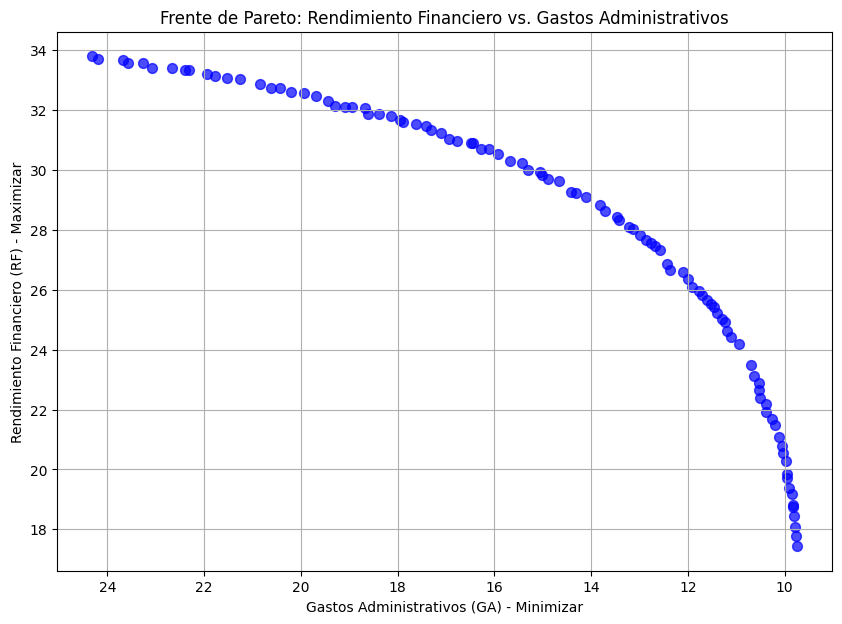

In [ ]:
# 6.1. Visualización del Frente de Pareto
plt.figure(figsize=(10, 7))
plt.scatter(pareto_ga, pareto_rf, s=50, facecolors='blue', edgecolors='blue', alpha=0.7)
plt.title('Frente de Pareto: Rendimiento Financiero vs. Gastos Administrativos')
plt.xlabel('Gastos Administrativos (GA) - Minimizar')
plt.ylabel('Rendimiento Financiero (RF) - Maximizar')
plt.grid(True)
plt.gca().invert_xaxis() # Opcional: A veces es intuitivo tener "mejor" hacia la derecha para minimizar
 # Pero el estándar es menor a la izquierda, mayor a la derecha.
 # Para GA (minimizar), menor es mejor, así que lo dejamos estándar.
 # RF (maximizar), mayor es mejor, así que estándar está bien.
plt.show()

In [ ]:
# PROBLEMA ORIGINAL
pareto_rf_old = -res_old.F[:, 0]
pareto_ga_old = res_old.F[:, 1]
pareto_x1_old = res_old.X[:, 0]
pareto_x2_old = res_old.X[:, 1]

# PROBLEMA MODIFICADO
pareto_rf_new = -res_new.F[:, 0]
pareto_ga_new = res_new.F[:, 1]
pareto_x1_new = res_new.X[:, 0]
pareto_x2_new = res_new.X[:, 1]

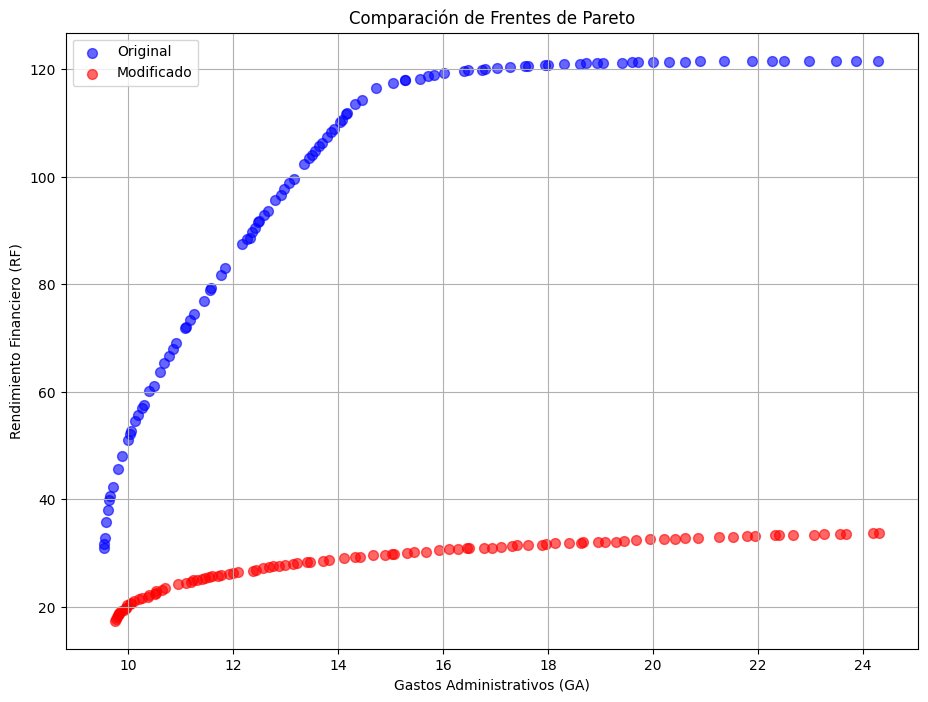

In [ ]:
plt.figure(figsize=(11, 8))

plt.scatter(pareto_ga_old, pareto_rf_old,
            c='blue', s=50, alpha=0.6, label='Original')

plt.scatter(pareto_ga_new, pareto_rf_new,
            c='red', s=50, alpha=0.6, label='Modificado')

plt.xlabel('Gastos Administrativos (GA)')
plt.ylabel('Rendimiento Financiero (RF)')
plt.title('Comparación de Frentes de Pareto')
plt.legend()
plt.grid(True)
plt.show()


## 7. Espacio de decisión coloreado por RF y GA


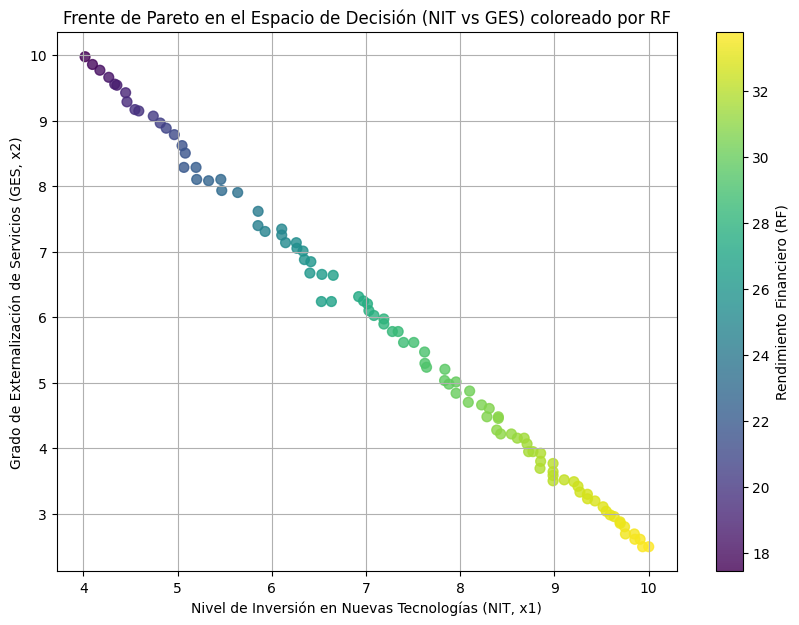

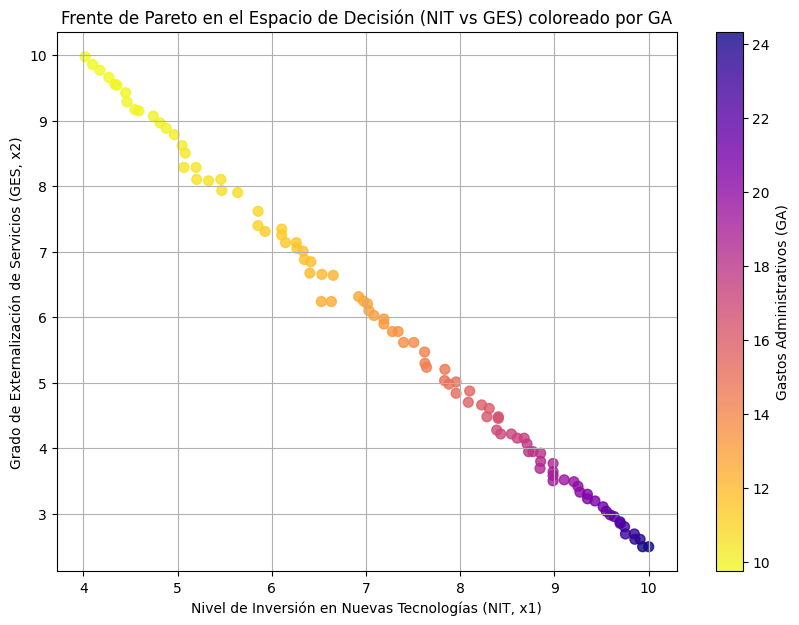

In [ ]:

# Espacio de decisión coloreado por RF
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pareto_x1, pareto_x2, c=pareto_rf, cmap='viridis', s=50, alpha=0.8)
plt.title('Frente de Pareto en el Espacio de Decisión (NIT vs GES) coloreado por RF')
plt.xlabel('Nivel de Inversión en Nuevas Tecnologías (NIT, x1)')
plt.ylabel('Grado de Externalización de Servicios (GES, x2)')
cbar = plt.colorbar(scatter, label='Rendimiento Financiero (RF)')
plt.grid(True)
plt.show()

# Espacio de decisión coloreado por GA
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pareto_x1, pareto_x2, c=pareto_ga, cmap='plasma_r', s=50, alpha=0.8)
plt.title('Frente de Pareto en el Espacio de Decisión (NIT vs GES) coloreado por GA')
plt.xlabel('Nivel de Inversión en Nuevas Tecnologías (NIT, x1)')
plt.ylabel('Grado de Externalización de Servicios (GES, x2)')
cbar = plt.colorbar(scatter, label='Gastos Administrativos (GA)')
plt.grid(True)
plt.show()


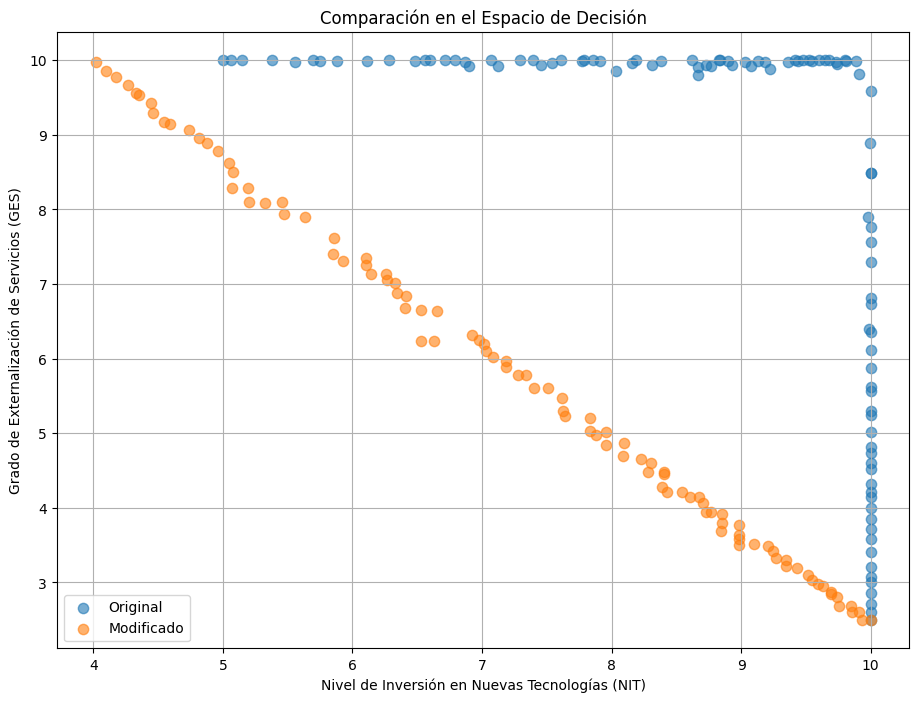

In [ ]:
plt.figure(figsize=(11, 8))

plt.scatter(
    pareto_x1_old, pareto_x2_old,
    s=55, alpha=0.6, label='Original'
)

plt.scatter(
    pareto_x1_new, pareto_x2_new,
    s=55, alpha=0.6, label='Modificado'
)

plt.xlabel('Nivel de Inversión en Nuevas Tecnologías (NIT)')
plt.ylabel('Grado de Externalización de Servicios (GES)')
plt.title('Comparación en el Espacio de Decisión')
plt.grid(True)
plt.legend()
plt.show()


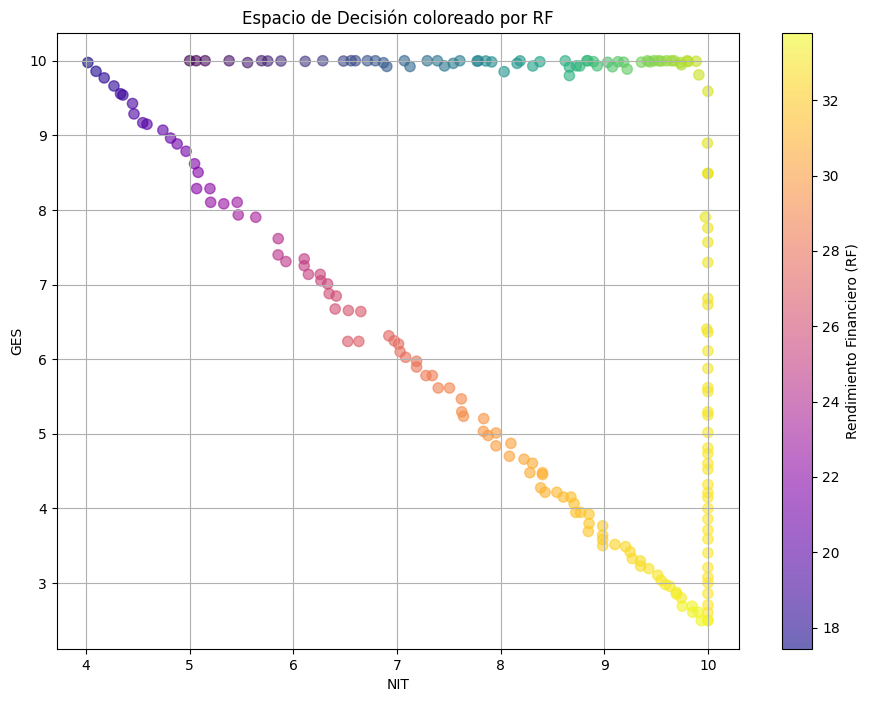

In [ ]:
plt.figure(figsize=(11, 8))

sc_old = plt.scatter(
    pareto_x1_old, pareto_x2_old,
    c=pareto_rf_old, cmap='viridis',
    s=55, alpha=0.6, label='Original'
)

sc_new = plt.scatter(
    pareto_x1_new, pareto_x2_new,
    c=pareto_rf_new, cmap='plasma',
    s=55, alpha=0.6, label='Modificado'
)

plt.xlabel('NIT')
plt.ylabel('GES')
plt.title('Espacio de Decisión coloreado por RF')
cbar = plt.colorbar(sc_new)
cbar.set_label('Rendimiento Financiero (RF)')
plt.grid(True)
plt.show()


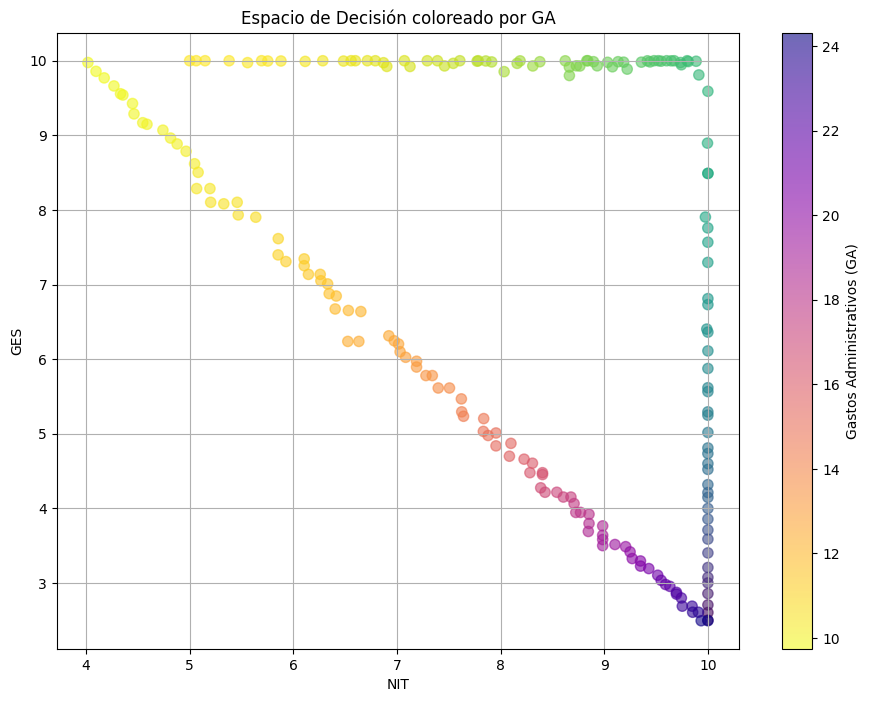

In [ ]:
plt.figure(figsize=(11, 8))

sc_old = plt.scatter(
    pareto_x1_old, pareto_x2_old,
    c=pareto_ga_old, cmap='viridis_r',
    s=55, alpha=0.6
)

sc_new = plt.scatter(
    pareto_x1_new, pareto_x2_new,
    c=pareto_ga_new, cmap='plasma_r',
    s=55, alpha=0.6
)

plt.xlabel('NIT')
plt.ylabel('GES')
plt.title('Espacio de Decisión coloreado por GA')
cbar = plt.colorbar(sc_new)
cbar.set_label('Gastos Administrativos (GA)')
plt.grid(True)
plt.show()



## 8. Análisis de resultados (Preguntas a, b, c)

> **a. ¿Cómo ha afectado la restricción presupuestaria al Frente de Pareto resultante?**  
Compara visualmente (o si puedes, superponiendo con el original, aunque no es estrictamente necesario para este reto) con el frente original. ¿Hay soluciones que antes eran alcanzables y ahora no lo son?

- La restricción \(x_1 + 0.8x_2 \le 12\) **recorta** el espacio de búsqueda, eliminando combinaciones de NIT y GES con valores simultáneamente altos.  
- En el frente original (sin restricción), eran posibles soluciones con **NIT alto y GES alto** (x1 y x2 grandes) que daban rendimientos muy elevados, aunque con gastos crecientes.  
- Con la restricción, esas soluciones dejan de ser factibles, por lo que el nuevo frente de Pareto:
  - Se desplaza hacia regiones con **menor combinación total de inversión**.
  - Muestra un límite natural donde no vemos puntos más allá de la frontera de presupuesto.
- Visualmente, la parte de soluciones que excedían el presupuesto porque el frente suele verse **más corto** y/o ligeramente desplazado.

---

> **b. ¿Cómo ha afectado la modificación de la función de Rendimiento Financiero (rendimientos decrecientes en x1) a la forma y posición del Frente de Pareto?**  

- Antes, con \((x_1 + 1)^2\), aumentar x1 crecía el RF de forma **muy rápida** (cuadrática), incentivando soluciones con NIT muy alto.  
- Con la nueva función \(10\sqrt{x_1 + 1}\), el crecimiento de RF con respecto a x1 se **suaviza**:
  - Las ganancias de aumentar x1 son fuertes al inicio, pero **cada unidad adicional aporta menos**.
- En el frente de Pareto modificado:
  - Las soluciones con NIT extremadamente alto **ya no dominan tan claramente** al resto, porque el beneficio extra es menor.
  - Se observan más soluciones de compromiso con valores de NIT **medios**, en donde el incremento en RF no sacrifica tanto GA ni presupuesto.
- En resumen, la forma del frente suele ser **menos “empinada”** en la zona de altos x1, reflejando los rendimientos decrecientes.

---

> **c. Observando el nuevo frente y las gráficas del espacio de decisión:  
> ¿Qué tipo de estrategias (NIT, GES) parecen ahora más prometedoras?  
> Si tuvieras que elegir UNA solución, ¿cuál recomendarías y por qué?**  

- Las gráficas en el espacio de decisión coloreadas por RF y GA permiten ver:
  - Zonas donde **RF es razonablemente alto** pero **GA no es extremo**, y
  - Zonas donde, además, la combinación \(x_1 + 0.8x_2\) se mantiene por debajo de 12.
- Típicamente, las estrategias más prometedoras bajo estas condiciones suelen ser:
  - **NIT moderado** donde ya se aprovecha el impulso inicial de la tecnología pero sin sobreinvertir.
  - **GES también moderado-alto**, lo suficiente para reducir gastos administrativos, pero sin excesos que perjudiquen el rendimiento ni rompan el presupuesto.

**Ejemplo de recomendación (conceptual):**  

> Elegiría una solución en la zona de “compromiso” del frente, donde:
> - El Rendimiento Financiero RF es **alto, pero no máximo absoluto**,  
> - Los Gastos Administrativos GA se mantienen en un nivel **controlado**,  
> - Y se respeta claramente la restricción de presupuesto.

En términos cualitativos, esta solución correspondería a:
- \(x_1\) en un valor **medio-alto pero no extremo** (p.ej. un NIT alrededor del centro del rango, donde el beneficio marginal aún es interesante).
- \(x_2\) en un valor que permita externalizar lo suficiente para bajar GA, pero sin perder demasiado control.

En una aplicación real, la decisión final se tomaría revisando puntos concretos del frente y contrastando RF, GA y el uso del presupuesto con las prioridades estratégicas de la dirección.

A continuación, se detallan las posibles soluciones:

Algunas soluciones del Frente de Pareto (x1: NIT, x2: GES, RF, GA):

Sol 1: NIT=10.00, GES=2.49 -> RF=33.79, GA=24.31

Sol 2: NIT=4.02, GES=9.98 -> RF=17.44, GA=9.75

Sol 3: NIT=9.43, GES=3.19 -> RF=32.87, GA=20.85

Sol 4: NIT=7.84, GES=5.20 -> RF=29.62, GA=14.67

Sol 5: NIT=9.52, GES=3.10 -> RF=33.02, GA=21.27

Sol 6: NIT=7.62, GES=5.47 -> RF=29.11, GA=14.11

Sol 7: NIT=6.63, GES=6.24 -> RF=26.86, GA=12.44

Sol 8: NIT=7.51, GES=5.61 -> RF=28.82, GA=13.82

Sol 9: NIT=6.92, GES=6.31 -> RF=27.32, GA=12.58

Sol 10: NIT=9.74, GES=2.80 -> RF=33.39, GA=22.67

## Trabajo Final: Aplicación del Frente de Pareto en mi entorno laboral

### Caso 1: Optimización de modelos de scoring crediticio en un banco
---
##### En un Banco de Ecuador, uno de los procesos clave es el diseño y calibración de modelos de scoring para la aprobación de créditos. Este proceso implica decisiones complejas con múltiples objetivos en conflicto. La optimización multiobjetivo con algoritmos como NSGA-II se presenta como una herramienta poderosa para apoyar la toma de decisiones estratégicas en este contexto.
---

## 1) Planteamiento del problema

Se dispone de un conjunto de variables predictivas, umbrales de aprobación y políticas de corte que determinan el comportamiento del modelo de scoring. El objetivo es calibrar estos parámetros considerando simultáneamente los siguientes objetivos conflictivos:

1. **Maximizar la rentabilidad esperada de la cartera**  
Aumentar los ingresos por intereses y comisiones mediante mayor aprobación y colocación.

2. **Minimizar el riesgo crediticio (pérdida esperada)**  
Reducir la probabilidad de mora (PD), severidad de la pérdida (LGD) y exposición al default (EAD).

3. **Maximizar la inclusión financiera**  
   Reducir costos asociados al desplazamiento de las cuadrillas, consumo de combustible y horas de trabajo.
Aumentar la tasa de aprobación en segmentos tradicionalmente excluidos (jóvenes, independientes, bajos ingresos) sin comprometer la estabilidad.

3. **Minimizar el impacto operativo**  
Reducir falsos positivos que generan revisiones manuales costosas y tiempos de respuesta largos al cliente.

Estos objetivos entran en conflicto natural. Por ejemplo, bajar umbrales para maximizar rentabilidad e inclusión aumenta el riesgo y las pérdidas esperadas, mientras que políticas muy conservadoras minimizan riesgo pero sacrifican crecimiento y acceso al crédito.

---

## 2) Variables de decisión

Variables de decisión
Las variables de decisión pueden definirse como:


- x₁: Umbral de score mínimo para aprobación automática
- x₂: Ponderación de variables de inclusión (peso asignado a atributos alternativos como comportamiento transaccional, datos abiertos, etc.)
- x₃: Nivel de segmentación (número y profundidad de reglas por segmento de riesgo) esto esta enfocado a los diferentes segementos personas, microempresas y empresas. Cada segmento tiene su particularidad.
- x₄: Intensidad de validación manual (porcentaje de casos enviados a revisión humana)

### Estas variables determinan el balance entre automatización, inclusión, riesgo y rentabilidad.
---

## 3) Formulación multiobjetivo

El problema puede formularse como:


- Maximizar f₁(x) = Rentabilidad esperada de la cartera
- Minimizar f₂(x) = Pérdida esperada (PD × LGD × EAD)

PD: Probabilidad de Incumplimiento
LDG: Pérdida Dado el Incumplimiento
EAD: Exposición al Incumplimiento


- Maximizar f₃(x) = Tasa de aprobación en segmentos de inclusión
- Minimizar f₄(x) = Costo operativo (revisiones manuales + tiempo de respuesta)

Sujeto a:

##### Restricciones regulatorias (Superintendencia de Bancos del Ecuador)
##### Límites de capital (Basilea)
##### Presupuesto operativo del área de riesgos
##### Requerimientos mínimos de aprobación por canal
---

## 4) Uso de un algoritmo multiobjetivo

Para resolver este problema se puede emplear NSGA-II (implementado con pymoo), que genera un Frente de Pareto con múltiples soluciones no dominadas. Cada solución representa un compromiso distinto:

Soluciones agresivas: alta rentabilidad e inclusión, pero mayor riesgo.
Soluciones conservadoras: mínimo riesgo, pero menor crecimiento y aprobación.
Soluciones equilibradas: buen balance entre todos los objetivos, ideales para operación estable.

---

## 5) Interpretación del Frente de Pareto

El equipo de Riesgos y la Alta Dirección pueden analizar el Frente de Pareto para seleccionar la calibración más adecuada según el contexto macroeconómico y estratégico:

- En períodos de expansión económica: elegir soluciones que maximicen rentabilidad e inclusión.
- En escenarios de recesión o alta incertidumbre: priorizar soluciones de bajo riesgo.
- En campañas de inclusión financiera: seleccionar puntos que maximicen aprobación en segmentos objetivo sin exceder límites de pérdida esperada.

- Este enfoque permite justificar técnicamente las decisiones ante reguladores y auditoría.

---

## 6) Ventajas del enfoque multiobjetivo en inspecciones de campo

- Visualiza claramente los trade-offs entre crecimiento, riesgo, inclusión y eficiencia operativa.
- Reduce la subjetividad al evitar pesos arbitrarios en funciones objetivo únicas.
- Facilita la adaptación dinámica del modelo ante cambios macroeconómicos o regulatorios.
- Mejora la transparencia y gobernanza del modelo, clave en entornos regulados.
---

## 7) Conclusión del ejemplo

> La optimización multiobjetivo aplicada a la calibración de modelos de scoring crediticio permite abordar de forma estructurada la complejidad inherente al negocio bancario, integrando simultáneamente criterios de rentabilidad, control de riesgo, inclusión financiera y eficiencia operativa. El uso de algoritmos evolutivos como NSGA-II proporciona un conjunto de soluciones óptimas de Pareto que apoyan a la dirección y al área de riesgos en la selección de la estrategia más adecuada según las prioridades del momento, mejorando la toma de decisiones informada, la competitividad del banco y el cumplimiento regulatorio con la Super Bancos.


### Caso 2: Inspecciones de campo georreferenciadas

En los procesos de inspección de campo, la planificación de las órdenes de trabajo implican **decisiones complejas con múltiples objetivos en conflicto**. En este contexto, la optimización multiobjetivo se presenta como una herramienta adecuada para apoyar la toma de decisiones.

---

## 1) Planteamiento del problema

Se dispone de un conjunto de órdenes georreferenciadas y un número limitado de cuadrillas técnicas. El objetivo es determinar el orden y la asignación de las inspecciones, considerando simultáneamente los siguientes objetivos:

1. **Minimizar el tiempo total de atención**  
   Reducir el tiempo de respuesta desde que se reporta una incidencia hasta que es atendida en campo.

2. **Minimizar el costo operativo**  
   Reducir costos asociados al desplazamiento de las cuadrillas, consumo de combustible y horas de trabajo.

3. **Maximizar la criticidad atendida**  
   Priorizar inspecciones con mayor nivel de riesgo o impacto.

4. **Minimizar la distancia recorrida**  
   Optimizar las rutas de las cuadrillas para reducir recorridos innecesarios.

Estos objetivos **entran en conflicto** de forma natural. Por ejemplo, atender primero una inspección crítica puede implicar mayores distancias o costos, mientras que minimizar costos podría retrasar eventos de alto riesgo.

---

## 2) Variables de decisión

Las variables de decisión pueden definirse como:

- \($ x_i $\): orden de atención de la inspección \($i $\)
- \($ y_{ij} $\): asignación de la inspección \($ i $\) a la cuadrilla \($j$\)

Estas variables determinan **qué inspección se atiende**, **cuándo** y **por quién**.

---

## 3) Formulación multiobjetivo

El problema puede formularse como:

- **Minimizar**  
  \[
  $f_1(x) = \text{Tiempo total de atención}$
  \]

- **Minimizar**  
  \[
  $f_2(x) = \text{Costo operativo total}$
  \]

- **Maximizar**  
  \[
  $f_3(x) = \text{Nivel de criticidad atendida}$
  \]

- **Minimizar**  
  \[
  $f_4(x) = \text{Distancia total recorrida}$
  \]

Sujeto a:
- Disponibilidad de cuadrillas
- Ventanas de tiempo (SLA)
- Capacidad técnica de cada cuadrilla

---

## 4) Uso de un algoritmo multiobjetivo

Para resolver este problema, se puede emplear un algoritmo como **NSGA-II o NSGA-III**, los cuales generan un **Frente de Pareto** compuesto por múltiples soluciones no dominadas.

Cada solución del frente representa un **compromiso distinto** entre los objetivos. Por ejemplo:

- Soluciones que priorizan **menor tiempo de respuesta**, pero con mayor costo.
- Soluciones que reducen costos y distancias, sacrificando ligeramente la criticidad atendida.
- Soluciones equilibradas, adecuadas para operación regular.

---

## 5) Interpretación del Frente de Pareto

El gestor de operaciones puede analizar el Frente de Pareto para seleccionar la solución más adecuada según el contexto operativo:

- En situaciones de emergencia, elegir soluciones que maximizan la criticidad atendida.
- En operación normal, seleccionar soluciones balanceadas en costo y tiempo.
- En contextos de restricción presupuestaria, priorizar soluciones de bajo costo.

Este enfoque permite **decisiones informadas y justificables**, en lugar de depender de una única solución arbitraria.

---

## 6) Ventajas del enfoque multiobjetivo en inspecciones de campo

- Permite **visualizar claramente los trade-offs** entre objetivos.
- Facilita la adaptación de la planificación a diferentes escenarios operativos.
- Reduce la subjetividad en la toma de decisiones.
- Escala adecuadamente ante múltiples órdenes y recursos limitados.

---

## 7) Conclusión del ejemplo

> La optimización multiobjetivo aplicada a inspecciones de campo georreferenciadas permite abordar de forma estructurada la complejidad de la planificación operativa, integrando simultáneamente criterios de tiempo, costo, criticidad y distancia. El uso de algoritmos evolutivos multiobjetivo proporciona un conjunto de soluciones óptimas que apoyan al gestor en la selección de la alternativa más adecuada según las prioridades del contexto, mejorando la eficiencia y la transparencia en la toma de decisiones.


## Caso 3: Asignación y planificación de tareas en equipos de desarrollo de software

# Ejemplo de aplicabilidad de la optimización multiobjetivo  

En los proyectos de desarrollo de software, la planificación de tareas y la asignación de recursos humanos implican **decisiones complejas con múltiples objetivos en conflicto**. En este contexto, la optimización multiobjetivo se presenta como una herramienta adecuada para apoyar la toma de decisiones en la gestión de proyectos.

---

## 1) Planteamiento del problema

Se dispone de un conjunto de tareas o historias de usuario (HU) pendientes y un equipo limitado de desarrolladores con distintas habilidades y niveles de experiencia. El objetivo es determinar **la asignación y el orden de ejecución de las tareas**, considerando simultáneamente los siguientes objetivos:

1. **Minimizar el tiempo total de desarrollo**  
   Reducir la duración del sprint o del proyecto para cumplir con los plazos establecidos.

2. **Minimizar el costo del proyecto**  
   Reducir el costo asociado al uso de recursos humanos, considerando horas de trabajo y niveles salariales.

3. **Maximizar el valor de negocio entregado**  
   Priorizar tareas que aportan mayor valor al cliente o al producto.

4. **Minimizar el desbalance de carga de trabajo del equipo**  
   Evitar la sobrecarga de algunos desarrolladores y la subutilización de otros.

Estos objetivos **entran en conflicto de manera natural**. Por ejemplo, asignar tareas críticas a los desarrolladores más experimentados puede reducir el tiempo de entrega, pero aumentar el costo y generar sobrecarga de trabajo.

---

## 2) Variables de decisión

Las variables de decisión pueden definirse como:

- \( x_i \): orden de ejecución de la tarea \( i \)
- \( y_{ij} \): asignación de la tarea \( i \) al desarrollador \( j \)

Estas variables determinan **qué tarea se desarrolla**, **en qué momento** y **por quién**.

---

## 3) Formulación multiobjetivo

El problema puede formularse como:

- **Minimizar**  
  \[
  $f_1(x) = \text{Tiempo total de desarrollo}$
  \]

- **Minimizar**  
  \[
  $f_2(x) = \text{Costo total del proyecto}$
  \]

- **Maximizar**  
  \[
  $f_3(x) = \text{Valor de negocio entregado}$
  \]

- **Minimizar**  
  \[
  $f_4(x) = \text{Desbalance de carga de trabajo del equipo}$
  \]

Sujeto a:
- Disponibilidad de los desarrolladores
- Capacidades técnicas requeridas por cada tarea
- Dependencias entre tareas
- Restricciones de tiempo del sprint o proyecto

---

## 4) Uso de un algoritmo multiobjetivo

Para resolver este problema, se puede emplear un algoritmo como **NSGA-II o NSGA-III**, los cuales generan un **Frente de Pareto** compuesto por múltiples soluciones no dominadas.

Cada solución del frente representa un **compromiso distinto** entre los objetivos. Por ejemplo:

- Soluciones que minimizan el tiempo de desarrollo, pero incrementan el costo.
- Soluciones que priorizan el valor de negocio, sacrificando el balance de carga.
- Soluciones equilibradas, adecuadas para sprints regulares.

---

## 5) Interpretación del Frente de Pareto

El líder técnico o gestor del proyecto puede analizar el Frente de Pareto para seleccionar la solución más adecuada según el contexto del proyecto:

- En entregas críticas, elegir soluciones que maximizan el valor de negocio.
- En contextos de restricción presupuestaria, priorizar soluciones de menor costo.
- En equipos con riesgo de agotamiento, seleccionar soluciones con mejor balance de carga.

Este enfoque permite **decisiones fundamentadas y transparentes**, en lugar de depender de una única planificación rígida.

---

## 6) Ventajas del enfoque multiobjetivo en desarrollo de software

- Permite **visualizar claramente los trade-offs** entre tiempo, costo, valor y carga de trabajo.
- Mejora la planificación de sprints y proyectos complejos.
- Reduce la subjetividad en la asignación de tareas.
- Se adapta fácilmente a cambios en requisitos o recursos.

---

## 7) Conclusión del ejemplo

> La optimización multiobjetivo aplicada a la planificación y asignación de tareas en equipos de desarrollo de software permite abordar de forma estructurada la complejidad inherente a los proyectos tecnológicos. Al integrar simultáneamente criterios de tiempo, costo, valor de negocio y equilibrio del equipo, los algoritmos evolutivos multiobjetivo generan un conjunto de soluciones óptimas que apoyan al gestor en la selección de la alternativa más adecuada según las prioridades del proyecto, mejorando la eficiencia, la sostenibilidad del equipo y la calidad del producto final.

